In [58]:
from pathlib import Path
from functools import partial
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [2]:
data_dir = Path("/mnt/d/Data/NCAR")

In [4]:
flist = sorted(data_dir.glob("hgt.????.nc"))
print(flist)

[PosixPath('/mnt/d/Data/NCAR/hgt.1979.nc'), PosixPath('/mnt/d/Data/NCAR/hgt.1980.nc'), PosixPath('/mnt/d/Data/NCAR/hgt.1981.nc'), PosixPath('/mnt/d/Data/NCAR/hgt.1982.nc'), PosixPath('/mnt/d/Data/NCAR/hgt.1983.nc'), PosixPath('/mnt/d/Data/NCAR/hgt.1984.nc'), PosixPath('/mnt/d/Data/NCAR/hgt.1985.nc'), PosixPath('/mnt/d/Data/NCAR/hgt.1986.nc'), PosixPath('/mnt/d/Data/NCAR/hgt.1987.nc'), PosixPath('/mnt/d/Data/NCAR/hgt.1988.nc'), PosixPath('/mnt/d/Data/NCAR/hgt.1989.nc'), PosixPath('/mnt/d/Data/NCAR/hgt.1990.nc'), PosixPath('/mnt/d/Data/NCAR/hgt.1991.nc'), PosixPath('/mnt/d/Data/NCAR/hgt.1992.nc'), PosixPath('/mnt/d/Data/NCAR/hgt.1993.nc'), PosixPath('/mnt/d/Data/NCAR/hgt.1994.nc'), PosixPath('/mnt/d/Data/NCAR/hgt.1995.nc'), PosixPath('/mnt/d/Data/NCAR/hgt.1996.nc'), PosixPath('/mnt/d/Data/NCAR/hgt.1997.nc'), PosixPath('/mnt/d/Data/NCAR/hgt.1998.nc'), PosixPath('/mnt/d/Data/NCAR/hgt.1999.nc'), PosixPath('/mnt/d/Data/NCAR/hgt.2000.nc'), PosixPath('/mnt/d/Data/NCAR/hgt.2001.nc'), PosixPath(

In [28]:
def _preprocess(ds):
    return ds[["hgt"]].sel(level=850.0)

In [33]:
ds = xr.open_mfdataset(flist, preprocess=partial(_preprocess))
ds = ds.sel(time=slice("1982", "2025"))
print(ds)

<xarray.Dataset> Size: 676MB
Dimensions:  (time: 16071, lat: 73, lon: 144)
Coordinates:
    level    float32 4B 850.0
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 129kB 1982-01-01 1982-01-02 ... 2025-12-31
Data variables:
    hgt      (time, lat, lon) float32 676MB dask.array<chunksize=(1, 73, 144), meta=np.ndarray>
Attributes:
    Conventions:    CF-1.0
    title:          daily NCEP/DOE Reanalysis 2
    comments:       Data is from \nNCEP/DOE AMIP-II Reanalysis (Reanalysis-2)...
    platform:       Model
    source:         NCEP/DOE AMIP-II Reanalysis (Reanalysis-2) Model
    institution:    National Centers for Environmental Prediction
    dataset_title:  NCEP-DOE AMIP-II Reanalysis
    References:     https://www.psl.noaa.gov/data/gridded/data.ncep.reanalysi...
    source_url:     http://www.cpc.ncep.noaa.gov/products/wesley/reanalys

In [34]:
clim = ds['hgt'].groupby('time.dayofyear').mean(dim='time').compute()
print(clim)

<xarray.DataArray 'hgt' (dayofyear: 366, lat: 73, lon: 144)> Size: 15MB
array([[[1305.1818, 1305.1818, 1305.1818, ..., 1305.1818, 1305.1818,
         1305.1818],
        [1293.2102, 1293.4829, 1293.8977, ..., 1292.0682, 1292.466 ,
         1292.75  ],
        [1284.375 , 1285.2898, 1286.0739, ..., 1282.3523, 1283.0114,
         1283.6989],
        ...,
        [1256.5057, 1258.716 , 1260.784 , ..., 1250.0398, 1252.2216,
         1254.4034],
        [1263.341 , 1264.341 , 1265.5966, ..., 1259.8921, 1261.0057,
         1262.1704],
        [1260.1307, 1260.1307, 1260.1307, ..., 1260.1307, 1260.1307,
         1260.1307]],

       [[1304.2727, 1304.2727, 1304.2727, ..., 1304.2727, 1304.2727,
         1304.2727],
        [1296.9716, 1297.1704, 1297.341 , ..., 1296.5682, 1296.7386,
         1296.8636],
        [1289.6989, 1290.1307, 1290.4716, ..., 1289.0398, 1289.159 ,
         1289.4829],
...
        [1255.7046, 1257.9148, 1260.159 , ..., 1249.0625, 1251.25  ,
         1253.4489],
        [

In [35]:
anom = ds['hgt'].groupby('time.dayofyear') - clim
print(anom)

<xarray.DataArray 'hgt' (time: 16071, lat: 73, lon: 144)> Size: 676MB
dask.array<sub, shape=(16071, 73, 144), dtype=float32, chunksize=(1, 73, 144), chunktype=numpy.ndarray>
Coordinates:
    level      (time) float32 64kB 850.0 850.0 850.0 850.0 ... 850.0 850.0 850.0
  * lat        (lat) float32 292B 90.0 87.5 85.0 82.5 ... -85.0 -87.5 -90.0
  * lon        (lon) float32 576B 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * time       (time) datetime64[ns] 129kB 1982-01-01 1982-01-02 ... 2025-12-31
    dayofyear  (time) int64 129kB 1 2 3 4 5 6 7 ... 359 360 361 362 363 364 365


In [37]:
anom_jja = anom.sel(time=anom.time.dt.month.isin([6, 7, 8])).compute()
print(anom_jja)

<xarray.DataArray 'hgt' (time: 4048, lat: 73, lon: 144)> Size: 170MB
array([[[ 33.335205 ,  33.335205 ,  33.335205 , ...,  33.335205 ,
          33.335205 ,  33.335205 ],
        [ 27.346558 ,  27.619263 ,  27.840942 , ...,  27.585205 ,
          27.852295 ,  28.01709  ],
        [ 21.721558 ,  22.07959  ,  21.4375   , ...,  22.6875   ,
          22.01709  ,  22.4375   ],
        ...,
        [-23.45459  , -20.29541  , -16.897705 , ..., -32.181763 ,
         -28.931763 , -26.823853 ],
        [-23.318237 , -22.551147 , -20.693237 , ..., -27.693237 ,
         -26.994263 , -25.153442 ],
        [-27.659058 , -27.659058 , -27.659058 , ..., -27.659058 ,
         -27.659058 , -27.659058 ]],

       [[ 32.431763 ,  32.431763 ,  32.431763 , ...,  32.431763 ,
          32.431763 ,  32.431763 ],
        [ 31.880737 ,  31.125    ,  30.556763 , ...,  32.863647 ,
          33.215942 ,  32.505737 ],
        [ 24.897705 ,  24.386353 ,  23.9375   , ...,  26.198853 ,
          25.721558 ,  25.25     ]

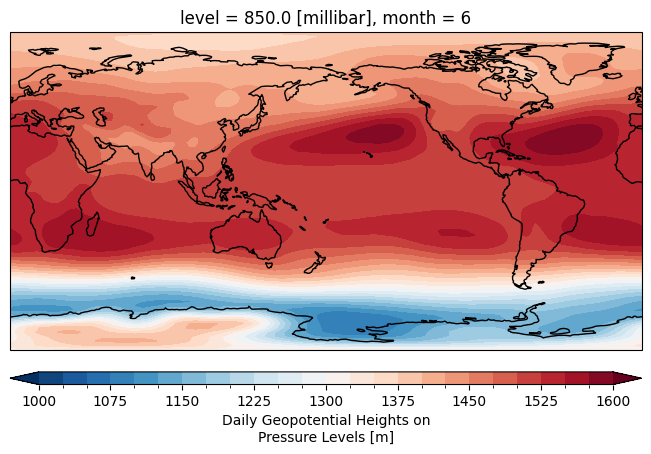

In [65]:
fig, ax = plt.subplots(layout='constrained', subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
ds['hgt'].groupby('time.month').mean(dim='time')[5].plot.contourf(vmin=1000, vmax=1600, levels=np.arange(1000, 1625, 25), extend="both", transform=ccrs.PlateCarree(), cmap="RdBu_r", cbar_kwargs=dict(orientation="horizontal", aspect=50))
ax.coastlines()

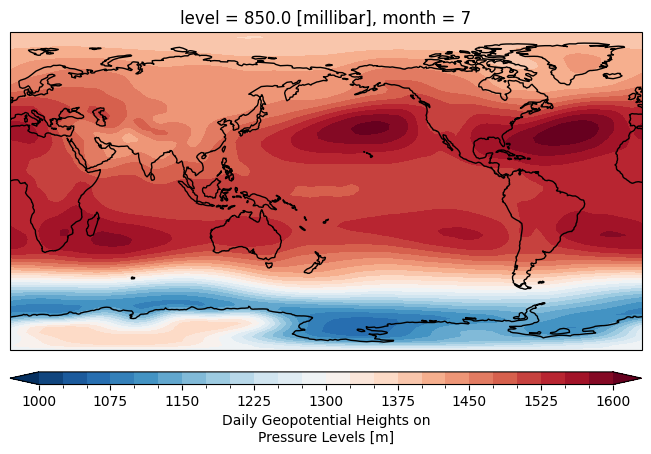

In [66]:
fig, ax = plt.subplots(layout='constrained', subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
ds['hgt'].groupby('time.month').mean(dim='time')[6].plot.contourf(vmin=1000, vmax=1600, levels=np.arange(1000, 1625, 25), extend="both", transform=ccrs.PlateCarree(), cmap="RdBu_r", cbar_kwargs=dict(orientation="horizontal", aspect=50))
ax.coastlines()

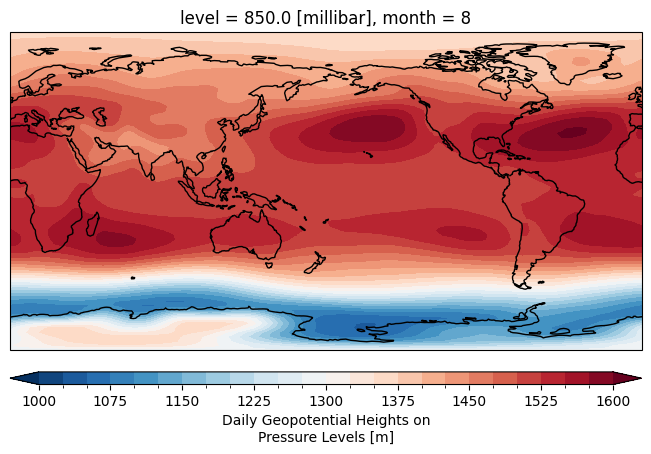

In [67]:
fig, ax = plt.subplots(layout='constrained', subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
ds['hgt'].groupby('time.month').mean(dim='time')[7].plot.contourf(vmin=1000, vmax=1600, levels=np.arange(1000, 1625, 25), extend="both", transform=ccrs.PlateCarree(), cmap="RdBu_r", cbar_kwargs=dict(orientation="horizontal", aspect=50))
ax.coastlines()

In [71]:
anom_jja.to_netcdf("../../data/hgt_850_jja_1982_2025.nc")

In [68]:
import os
os.getcwd()

'/home/user/EASM/notebooks/preprocessing'